## 🚀 STEP 1: Load Dataset & Basic Inspection

In [12]:
!pip install joblib scikit-learn

  Using cached scikit_learn-1.8.0-cp311-cp311-win_amd64.whl.metadata (11 kB)
  Using cached scipy-1.17.1-cp311-cp311-win_amd64.whl.metadata (60 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.8.0-cp311-cp311-win_amd64.whl (8.1 MB)
Using cached scipy-1.17.1-cp311-cp311-win_amd64.whl (36.6 MB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)

   ------------- -------------------------- 1/3 [scipy]
   ------------- -------------------------- 1/3 [scipy]
   ------------- -------------------------- 1/3 [scipy]
   ------------- -------------------------- 1/3 [scipy]
   ------------- -------------------------- 1/3 [scipy]
   ------------- -------------------------- 1/3 [scipy]
   ------------- -------------------------- 1/3 [scipy]
   ------------- -------------------------- 1/3 [scipy]
   ------------- -------------------------- 1/3 [scipy]
   ------------- -------------------------- 1/3 [scipy]
   ------------- ------------------


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np

df = pd.read_csv("Beijing Air Quality from 2010 to 2017.csv")

print("Shape:", df.shape)
print("\nFirst 3 rows:")
print(df.head(3))
print("\nMissing value % per column:")
missing_pct = (df.isnull().sum() / len(df) * 100).round(1)
print(missing_pct[missing_pct > 0].sort_values(ascending=False))

Shape: (473352, 25)

First 3 rows:
      City Country                  Date  Season  \
0  Beijing   China  3/1/2013 12:00:00 AM  Winter   
1  Beijing   China   3/1/2013 1:00:00 AM  Winter   
2  Beijing   China   3/1/2013 2:00:00 AM  Winter   

   PM2.5 concentration (ug/m^3)  PM_Station 3  Dew Point (Fahrenheit)  \
0                           9.0           NaN                   -2.20   
1                          11.0           NaN                   -2.74   
2                           8.0           NaN                   -3.46   

   Temperature (Fahrenheit)  PM2.5  PM10 concentration (ug/m^3)  ...  \
0                      32.0    9.0                          9.0  ...   
1                      32.0   11.0                         11.0  ...   
2                      32.0    8.0                          8.0  ...   

   Pressure (hPa)  Wind Direction  Wind Speed (m/s)  \
0          1021.0             WNW               2.0   
1          1022.0             WNW               4.4   
2        

## 🚀 STEP 2: Data Preprocessing

Remove leaky columns (other PM2.5 station readings), drop sparse columns (>50% missing), parse datetime, and forward-fill remaining gaps.

In [4]:
# Drop leaky columns — other PM2.5 station readings cause direct data leakage
leaky_cols = ['PM_Station 1', 'PM_Station 2', 'PM_Station 3', 'PM_US Post']
df.drop(columns=[c for c in leaky_cols if c in df.columns], inplace=True)

# Drop redundant columns
redundant_cols = ['City', 'Country', 'PM2.5',
                  'Temperature (Fahrenheit)', 'Dew Point (Fahrenheit)']
df.drop(columns=[c for c in redundant_cols if c in df.columns], inplace=True)

# Rename target
df.rename(columns={'PM2.5 concentration (ug/m^3)': 'PM2.5_target'}, inplace=True)

# Parse datetime and sort chronologically
df['datetime'] = pd.to_datetime(df['Date'])
df.drop(columns=['Date'], inplace=True)
df.sort_values('datetime', inplace=True)
df.reset_index(drop=True, inplace=True)

# Drop sparse columns (>50% missing) — noise, not signal
before = df.shape[1]
df = df.loc[:, df.isnull().mean() < 0.5]
print(f"Dropped {before - df.shape[1]} sparse column(s).")
print("Remaining columns:", df.columns.tolist())

# Forward-fill remaining gaps (time-series appropriate — use last known reading)
df.ffill(inplace=True)
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

print(f"\nShape after preprocessing: {df.shape}")
print(f"Missing values remaining: {df.isnull().sum().sum()}")

C:\Users\manoj kulkarni\AppData\Local\Temp\ipykernel_12620\527436682.py:14: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['datetime'] = pd.to_datetime(df['Date'])


Dropped 2 sparse column(s).
Remaining columns: ['Season', 'PM2.5_target', 'PM10 concentration (ug/m^3)', 'SO2 concentration (ug/m^3)', 'NO2 concentration (ug/m^3)', 'CO concentration (ug/m^3)', 'O3 concentration (ug/m^3)', 'Pressure (hPa)', 'Wind Direction', 'Wind Speed (m/s)', 'Precipitation (mm, hourly)', 'Dew Point (Celsius)', 'Temperature (Celsius)', 'datetime']

Shape after preprocessing: (445631, 14)
Missing values remaining: 0


## 🚀 STEP 3: Feature Engineering

Encode categoricals, extract temporal features, create lag/rolling features, compute EPA AQI, and create multi-horizon forecast targets.

In [7]:
import joblib

# Save categorical encodings for consistent deployment
season_encoding = {cat: i for i, cat in enumerate(sorted(df['Season'].dropna().unique()))}
wd_encoding     = {cat: i for i, cat in enumerate(sorted(df['Wind Direction'].dropna().unique()))}
joblib.dump(season_encoding, "season_encoding.pkl")
joblib.dump(wd_encoding,     "wind_direction_encoding.pkl")

df['Season']         = df['Season'].map(season_encoding)
df['Wind Direction'] = df['Wind Direction'].map(wd_encoding)

# Temporal features
df['hour']      = df['datetime'].dt.hour
df['day']       = df['datetime'].dt.day
df['month']     = df['datetime'].dt.month
df['dayofweek'] = df['datetime'].dt.dayofweek

# Lag features — historical PM2.5 available at prediction time
df['PM2.5_lag1']       = df['PM2.5_target'].shift(1)
df['PM2.5_lag3']       = df['PM2.5_target'].shift(3)
df['PM2.5_rolling6h']  = df['PM2.5_target'].rolling(6).mean()
df['PM2.5_rolling24h'] = df['PM2.5_target'].rolling(24).mean()

# Forecast targets — future values to predict
df['PM2.5_t1']  = df['PM2.5_target'].shift(-1)    # 1 hour ahead
df['PM2.5_t6']  = df['PM2.5_target'].shift(-6)    # 6 hours ahead
df['PM2.5_t24'] = df['PM2.5_target'].shift(-24)   # 24 hours ahead

# EPA piecewise linear AQI formula
def pm25_to_aqi(pm):
    breakpoints = [
        (0.0,    12.0,   0,  50),
        (12.1,   35.4,  51, 100),
        (35.5,   55.4, 101, 150),
        (55.5,  150.4, 151, 200),
        (150.5, 250.4, 201, 300),
        (250.5, 500.4, 301, 500),
    ]
    for bp_lo, bp_hi, aqi_lo, aqi_hi in breakpoints:
        if bp_lo <= pm <= bp_hi:
            return round(((aqi_hi - aqi_lo) / (bp_hi - bp_lo)) * (pm - bp_lo) + aqi_lo)
    return 500

df['AQI'] = df['PM2.5_target'].apply(pm25_to_aqi)

# Drop original target and datetime — not available at inference time
df.drop(columns=['datetime', 'PM2.5_target'], inplace=True)
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

print("Feature engineering complete. Shape:", df.shape)
print("\nAQI distribution:")
print(df['AQI'].describe().round(1))

Feature engineering complete. Shape: (445584, 24)

AQI distribution:
count    445584.0
mean        138.9
std          82.9
min           4.0
25%          70.0
50%         151.0
75%         180.0
max         500.0
Name: AQI, dtype: float64


## 🚀 STEP 4: Chronological Train/Test Split

Time series data must split by time order — random shuffling leaks future data into training.

In [8]:
TARGET_COLS     = ['PM2.5_t1', 'PM2.5_t6', 'PM2.5_t24', 'AQI']
feature_columns = [c for c in df.columns if c not in TARGET_COLS]

# Chronological 80/20 split — NO random shuffling
split_idx = int(len(df) * 0.8)
train_df  = df.iloc[:split_idx]
test_df   = df.iloc[split_idx:]

X_train = train_df[feature_columns]
X_test  = test_df[feature_columns]

joblib.dump(feature_columns, "features.pkl")

print(f"Train: {len(train_df):,} rows  |  Test: {len(test_df):,} rows")
print(f"\nFeatures ({len(feature_columns)}):")
for col in feature_columns:
    print(f"  - {col}")

Train: 356,467 rows  |  Test: 89,117 rows

Features (20):
  - Season
  - PM10 concentration (ug/m^3)
  - SO2 concentration (ug/m^3)
  - NO2 concentration (ug/m^3)
  - CO concentration (ug/m^3)
  - O3 concentration (ug/m^3)
  - Pressure (hPa)
  - Wind Direction
  - Wind Speed (m/s)
  - Precipitation (mm, hourly)
  - Dew Point (Celsius)
  - Temperature (Celsius)
  - hour
  - day
  - month
  - dayofweek
  - PM2.5_lag1
  - PM2.5_lag3
  - PM2.5_rolling6h
  - PM2.5_rolling24h


## 🚀 STEP 5: Train Models (3 Forecast Horizons)

One Random Forest per horizon: t+1h, t+6h, t+24h.

In [14]:
from sklearn.ensemble import RandomForestRegressor

HORIZONS = {
    't1':  'PM2.5_t1',
    't6':  'PM2.5_t6',
    't24': 'PM2.5_t24',
}

models      = {}
predictions = {}

for horizon, target_col in HORIZONS.items():
    y_train = train_df[target_col]
    y_test  = test_df[target_col]

    model = RandomForestRegressor(
        n_estimators=50,       # 50 trees is enough; 100 doubles memory for marginal gain
        max_depth=20,          # caps tree size -- prevents exponential memory growth
        max_samples=100_000,   # each tree bootstraps 100k rows instead of all 356k
        n_jobs=1,              # single-threaded -- parallel copies multiply RAM usage
        random_state=42,
    )
    model.fit(X_train, y_train)

    preds = model.predict(X_test)
    models[horizon]      = model
    predictions[horizon] = (y_test.values, preds)

    joblib.dump(model, f"air_quality_model_{horizon}.pkl")
    print(f"Model {horizon} trained and saved.")

Model t1 trained and saved.
Model t6 trained and saved.
Model t24 trained and saved.


## 🚀 STEP 6: Model Evaluation

In [15]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print(f"{'Horizon':<12} {'MAE':>8} {'RMSE':>8} {'R2':>8}")
print("-" * 42)

for horizon in HORIZONS:
    y_true, y_pred = predictions[horizon]
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f"t+{horizon[1:]:<10} {mae:>8.2f} {rmse:>8.2f} {r2:>8.4f}")

print("\nNote: R2 reflects genuine forecasting ability — no leaky station columns.")

Horizon           MAE     RMSE       R2
------------------------------------------
t+1             17.12    30.93   0.8583
t+6             17.48    31.39   0.8541
t+24            20.56    36.31   0.8047

Note: R2 reflects genuine forecasting ability — no leaky station columns.


## 🚀 STEP 7: Feature Importance

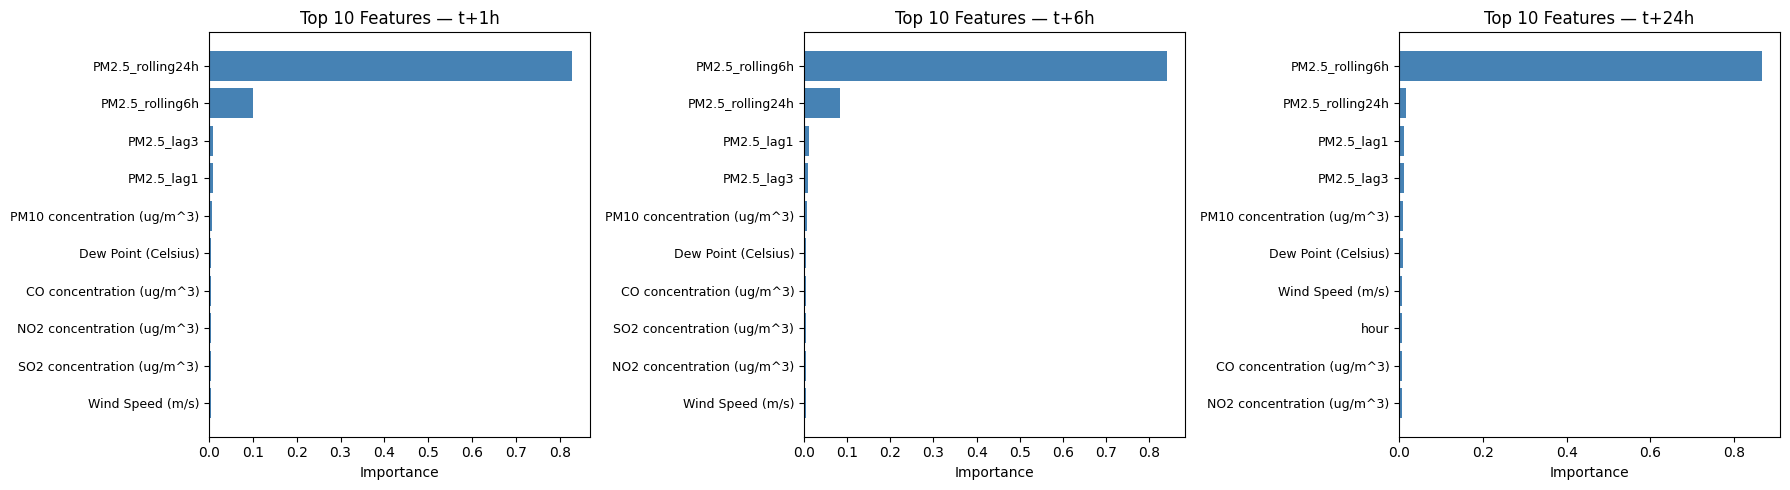

Saved as feature_importance.png


In [16]:
import matplotlib.pyplot as plt

TOP_N = 10
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (horizon, target_col) in enumerate(HORIZONS.items()):
    importances = models[horizon].feature_importances_
    indices     = np.argsort(importances)[-TOP_N:]

    axes[i].barh(range(TOP_N), importances[indices], color='steelblue')
    axes[i].set_yticks(range(TOP_N))
    axes[i].set_yticklabels([feature_columns[j] for j in indices], fontsize=9)
    axes[i].set_title(f"Top {TOP_N} Features — t+{horizon[1:]}h")
    axes[i].set_xlabel("Importance")

plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved as feature_importance.png")